# Quantum Battleships 
### This notebook implements a two‑player **Quantum Battleships** using the **Elitzur–Vaidman (E‑V)** bomb tester and the **Quantum Zeno effect**. You can **play** a duel and run an **optimizer** that sweeps strategies/parameters to recommend an efficient choice.

---

## Essential Theory

**Interaction‑Free Measurement (Elitzur–Vaidman, 1993).**  
You can detect a “live bomb” without detonating it using interference. A photon only takes a certain path if no absorber is present; if absorption is *possible* and we interrogate frequently, the **Quantum Zeno effect** inhibits the transition, allowing us to infer the presence **without interaction** with high probability.

**Quantum Zeno Effect (Misra–Sudarshan, 1977).**  
Frequent measurement (or effective which‑path interrogation) prevents state evolution. In an idealized Zeno interrogation with depth `N`, a live bomb has
$(
p_{\text{explode}} \approx \frac{\pi^2}{4N},\quad
p_{\text{found}} \approx 1 - \frac{\pi^2}{4N}
)$
per probe over a region that truly contains a bomb/ship.

**Our circuit model (Qiskit).**  
We encode a single “path” qubit `qP` and a bomb ancilla `qB`. Each **Zeno step** applies a small rotation to `qP`, then CNOTs to `qB`, **measures** `qB`, and **resets** it. Measuring any ancilla bit as `1` counts as an **Explosion** for that shot. If no explosion occurs and the final detector on `qP` outputs `0`, we call it **Bomb Found** (interaction‑free). Otherwise it is **Empty**.

**Game**  
A secret mission to find ships of the enemy without them noticing you, they put bombs on ships that will be triggered if you are not careful enough
- Board is `M×M` with `S` hidden 1×1 ships with bombs on them.  
- A **probe subset** is a row, column, or rectangle of cells.  
- We run the Zeno circuit and sample one of: **Explosion**, **Found**, **Empty**.  
- After a **positive** result (Found/Explosion), we **subdivide** the region for finer localization (group testing).  
- **Explosion penalty:** each explosion adds extra **turns used** to the acting player.

**EV score (used for wins/tie‑breaks).**
$
\textbf{EV} \;=\;[ \frac{\#\text{Found}}{max(\#\text{Explosions},1)}
]$
Intuition: reward interaction‑free detections relative to harmful explosions.

---

## Methods (what’s implemented)

1. **Strategies**: `rows`, `cols`, and `binary` (rectangle splits). They manage a **queue of regions** to probe and **subdivide** on positive signals.  
2. **Zeno probe**: `N` steps → ~`N` CNOT+measure pairs; higher `N` reduces explosion probability but increases gate cost.  
3. **Duel engine**: Alternating turns; track `EV`, `turns_used` (with penalty), `gates`, and `probes`. Win by sinking all ships or via EV tie‑breakers.
4. **Optimizer**: Fast Monte Carlo over `(method, N)` under optional **gate** or **turn** budgets; ranks by EV with sensible tie‑breakers (lower cost, then fewer probes).

In [1]:
import math, random
import numpy as np
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

from IPython.display import display, clear_output
import ipywidgets as widgets
import pandas as pd

## Zeno Probe Circuit
Build and simulate the Zeno‑style E‑V probe with mid‑circuit measurement and reset.

In [2]:
def zeno_probe(N: int) -> QuantumCircuit:
    """Build a Zeno E‑V probe circuit with N weak steps.

    Purpose
    -------
    Construct a parameterized probe that executes `N` small rotations on a path
    qubit `qP`, each followed by a whichpath interrogation using ancilla `qB`
    with **mid‑circuit measurement** and **reset**. Measuring any ancilla bit
    as `1` is treated as an **Explosion** for that shot. If no explosion occurs,
    we measure `qP` at the end to decide **Found** vs **Empty**.

    Parameters
    ----------
    N : int
        Number of Zeno steps (>=1). Also proxies two‑qubit gate cost (~1 CNOT per step).

    Returns
    -------
    QuantumCircuit
        Qubits: `qP` (path), `qB` (bomb ancilla).  
        Classical: `c_exp[N]` (explosion flags), `c_det[1]` (final detector).

    Notes
    -----
    - Small‑angle per step is θ = π/(2N) so that the empty‑subset evolution
      approximates a net π rotation after N steps.
    - Higher `N` typically reduces explosion probability: p_explode ≈ π²/(4N).
    """
    assert N >= 1, "Zeno depth N must be >= 1"

    # Allocate quantum and classical registers
    qP = QuantumRegister(1, 'qP')
    qB = QuantumRegister(1, 'qB')
    c_exp = ClassicalRegister(N, 'c_exp')
    c_det = ClassicalRegister(1, 'c_det')
    qc = QuantumCircuit(qP, qB, c_exp, c_det, name=f"Zeno(N={N})")

    # Each Zeno step: small rotation + interrogation + measure/reset ancilla
    theta = math.pi/(2*N)
    for k in range(N):
        qc.ry(2*theta, qP)   # weak "beam splitter"
        qc.cx(qP, qB)        # which‑path interrogation
        qc.measure(qB, c_exp[k])
        qc.reset(qB)         # prepare ancilla for the next step

    # Final detector for the path qubit
    qc.measure(qP, c_det)
    return qc

def run_and_classify(qc: QuantumCircuit, shots: int = 512) -> Dict[str, float]:
    """Simulate a probe circuit and report outcome frequencies.

    Purpose
    -------
    Execute `qc` on AerSimulator and convert shot bitstrings into the three
    outcome frequencies used by the game: 'explosion', 'found', 'empty'.

    Parameters
    ----------
    qc : QuantumCircuit
        Probe circuit, typically from :func:`zeno_probe`.
    shots : int, optional
        Number of simulator shots, by default 512.

    Returns
    -------
    Dict[str, float]
        Frequencies summing to ~1 with keys: 'explosion', 'found', 'empty'.

    Notes
    -----
    - A shot is an **explosion** if **any** `c_exp` bit equals 1.
    - If no explosion, we check the final detector bit `c_det`:
        0 → **found**, 1 → **empty**.
    """
    backend = AerSimulator()
    tqc = transpile(qc, backend)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()

    # Aggregate counts into three tallies
    tallies = {'explosion': 0, 'found': 0, 'empty': 0}
    total = max(sum(counts.values()), 1)
    for bitstring, c in counts.items():
        det_bit = bitstring[-1] if len(bitstring) else '1'  # last bit is c_det
        exp_bits = bitstring[:-1]                           # prior bits are c_exp
        if '1' in exp_bits:
            tallies['explosion'] += c
        else:
            if det_bit == '0':
                tallies['found'] += c
            else:
                tallies['empty'] += c
    return {k: v/total for k, v in tallies.items()}

## Board Mechanics
Utilities for random boards, region enumeration, and ship removal.

**Representation.** The board is an `M×M` grid stored as a nested Python list (`List[List[int]]`), where `1` means a ship occupies that cell and `0` means empty. We place `S` non-overlapping 1×1 ships uniformly at random.

**Probe subsets.** Each turn you probe a **subset** of cells determined by the chosen strategy:
- **rows**: probe one whole row segment at a time.  
- **cols**: probe one whole column segment at a time.  
- **binary**: probe a rectangular region (covers large areas first, then splits).

**Queue & refinement (group testing).** Strategies maintain a **queue** of regions to test. After a **positive** signal (either *Found* or *Explosion*), the probed region is **subdivided** and its sub-regions are appended to the queue for finer localization. After a **negative** signal (*Empty*), we discard that region and move on.

**Outcomes & updates.**
- **Explosion**: any ancilla bit = `1` during the Zeno steps. We remove **one random ship** from the probed subset (if any). The attacker also pays an **explosion penalty** in *turns used*.  
- **Found**: no explosion and the final detector on the path qubit reads `0` → interaction-free detection (no ship is removed; this is a “clean” hit from an information perspective).  
- **Empty**: no explosion and final detector reads `1` → no evidence of ships in that region.

**Scoring & costs.**
- **EV score**
- **Turns used**: `+1` per probe, plus the configured **penalty** for each explosion.  
- **Gate cost proxy**: each probe uses roughly **`N` two-qubit operations** (≈ one per Zeno step), so total gates ≈ $\text{probes} \times N$.

**Simulator knobs.**  
- **N** (Zeno depth): larger `N` reduces explosion probability but increases gate cost.  
- **shots**: number of Aer simulator shots when estimating outcome frequencies.


In [3]:
def random_board(M: int, S: int, seed: int) -> List[List[int]]:
    """Create an M×M board with S randomly placed 1×1 ships.

    Purpose
    -------
    Sample a defender's board by placing `S` ships uniformly at random, no overlap.

    Parameters
    ----------
    M : int
        Board dimension.
    S : int
        Number of ships (0 ≤ S ≤ M*M).
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    List[List[int]]
        2D grid of 0/1 with 1 indicating a ship.
    """
    rng = random.Random(seed)
    cells = [(r, c) for r in range(M) for c in range(M)]
    rng.shuffle(cells)
    ships = set(cells[:S])
    return [[1 if (r, c) in ships else 0 for c in range(M)] for r in range(M)]


def ships_remaining(board: List[List[int]]) -> int:
    """Count remaining ships on a board.

    Parameters
    ----------
    board : List[List[int]]
        2D 0/1 grid.

    Returns
    -------
    int
        Number of ship cells still present.
    """
    return sum(sum(row) for row in board)


def subset_has_ship(board: List[List[int]], subset: List[Tuple[int, int]]) -> bool:
    """Check whether a subset of cells contains at least one ship.

    Parameters
    ----------
    board : List[List[int]]
        2D 0/1 grid.
    subset : List[Tuple[int,int]]
        Coordinates `(r, c)` to test.

    Returns
    -------
    bool
        True if any cell in subset has a ship; False otherwise.
    """
    return any(board[r][c] == 1 for r, c in subset)


def remove_random_ship_in_subset(board: List[List[int]], subset: List[Tuple[int, int]], seed: int) -> Optional[Tuple[int, int]]:
    """Remove one random ship from `subset`, if present.

    Purpose
    -------
    Model an **Explosion** by deleting a single ship from the probed region.

    Parameters
    ----------
    board : List[List[int]]
        Defender's board (modified in place).
    subset : List[Tuple[int,int]]
        Cells probed in this shot.
    seed : int
        RNG seed to choose which ship to remove.

    Returns
    -------
    Optional[Tuple[int,int]]
        Coordinates `(row, col)` of the removed ship, or `None` if none existed.
    """
    ships = [(r, c) for (r, c) in subset if board[r][c] == 1]
    if not ships:
        return None
    rng = random.Random(seed)
    r, c = rng.choice(ships)
    board[r][c] = 0
    return (r, c)


def rect_cells(r0: int, c0: int, r1: int, c1: int) -> List[Tuple[int, int]]:
    """Enumerate cells in rectangle [r0, r1) × [c0, c1).

    Returns
    -------
    List[Tuple[int,int]]
        List of `(r, c)` inside the rectangle.
    """
    return [(r, c) for r in range(r0, r1) for c in range(c0, c1)]


def split_rect(r0: int, c0: int, r1: int, c1: int) -> Tuple[Tuple[int, int, int, int], Tuple[int, int, int, int]]:
    """Split a rectangle roughly in half along its longer side.

    Parameters
    ----------
    r0, c0, r1, c1 : int
        Rectangle bounds with inclusive/exclusive semantics.

    Returns
    -------
    Tuple[rect, rect]
        Two rectangles `(r0, c0, r1, c1)` partitioning the input.
    """
    h = r1 - r0
    w = c1 - c0
    if h >= w:
        m = r0 + h // 2
        return (r0, c0, m, c1), (m, c0, r1, c1)
    else:
        m = c0 + w // 2
        return (r0, c0, r1, m), (r0, m, r1, c1)

# Scoring & Win Conditions

**What we track per player**
- **Found** — count of interaction-free detections (final detector = 0, no explosion).
- **Explosions** — count of bomb detonations (any ancilla = 1 during Zeno steps).
- **Probes** — number of probe actions taken.
- **Turns used** — `+1` per probe **plus** penalty for each explosion.
- **Gates (≈)** — proxy cost, roughly `probes × N` (one 2-qubit interrogation per Zeno step).

---

## Penalty model
- **Base turn cost:** every probe costs **+1 turn**.
- **Explosion penalty:** each explosion adds **`+P` turns** (configurable).
  - So after `E` explosions and `K` probes:  
    $[
    \textbf{Turns used} \;=\; K \;+\; P \cdot E
    ]$

---

## EV score (primary performance metric)
$
\textbf{EV} \;=\;[ \frac{\#\text{Found}}{max(\#\text{Explosions},1)}
]$
- Rewards **interaction-free success** relative to harmful explosions.
- Denominator is clamped at 1 to avoid division by zero when there are no explosions.

---

## How a game is won

1. **Immediate victory (sink all ships).**  
   - If you reduce the opponent’s remaining ships to **0** before they do the same to you, **you win** immediately.

2. **Round-limit decision (timeout).**  
   When the **round limit** is reached and both players still have ships:
   - Compare **EV**. The higher EV **wins**.
   - If **EV is tied**, apply **tie-breakers** in order:
     1. **Lower Turns used** (faster play / fewer penalties) wins.
     2. **Lower Gates** (more hardware-efficient) wins.
     3. **Fewer Probes** (leaner search) wins.
   - If still tied after all tiebreakers → **Draw**.

---


## Notes
- Increasing **Zeno depth** `N` typically **reduces explosion rate** (helps EV) but **increases gate cost**.
- A higher **penalty** `P` makes explosions more costly in **Turns used**, which influences tie-breakers and strategic choice of `N`.


## Strategy Queues: rows / cols / binary
We maintain a queue of regions to probe. After a **positive** result (Found/Explosion), we **subdivide** and enqueue sub‑regions.

In [4]:
@dataclass
class ScannerState:
    """Queue‑based region scanner for rows, columns, or binary rectangles.

    Attributes
    ----------
    method : str
        'rows', 'cols', or 'binary' (rectangles).
    M : int
        Board size.
    queue : list
        Pending regions. Format depends on method:
          - rows: (row, start_c, end_c)
          - cols: (col, start_r, end_r)
          - binary: (r0, c0, r1, c1)
    cursor : int
        Reserved for future iteration styles (not used here).
    """
    method: str
    M: int
    queue: list
    cursor: int = 0


def make_scanner(method: str, M: int) -> ScannerState:
    """Initialize a scanning queue covering the full board.

    Parameters
    ----------
    method : str
        Strategy label: 'rows', 'cols', or 'binary'.
    M : int
        Board dimension.

    Returns
    -------
    ScannerState
        Initialized queue of regions for the chosen strategy.
    """
    method = method.lower()
    if method == 'rows':
        return ScannerState('rows', M, [(r, 0, M) for r in range(M)], 0)
    if method == 'cols':
        return ScannerState('cols', M, [(c, 0, M) for c in range(M)], 0)
    return ScannerState('binary', M, [(0, 0, M, M)], 0)


def next_subset(state: ScannerState) -> List[Tuple[int, int]]:
    """Pop the next subset of cells to probe from the queue.

    Parameters
    ----------
    state : ScannerState
        Strategy state with pending regions.

    Returns
    -------
    List[Tuple[int,int]]
        List of `(r, c)` to probe (empty if queue is exhausted).
    """
    if not state.queue:
        return []
    if state.method == 'rows':
        r, a, b = state.queue.pop(0)
        return [(r, c) for c in range(a, b)]
    if state.method == 'cols':
        c, a, b = state.queue.pop(0)
        return [(r, c) for r in range(a, b)]
    r0, c0, r1, c1 = state.queue.pop(0)
    return rect_cells(r0, c0, r1, c1)


def feedback(state: ScannerState, subset: List[Tuple[int, int]], positive: bool) -> None:
    """Update the queue after a probe; subdivide on positive signal.

    Parameters
    ----------
    state : ScannerState
        Strategy state to update (in place).
    subset : List[Tuple[int,int]]
        Exact cells that were probed this turn.
    positive : bool
        True for Found/Explosion; False for Empty.
    """
    if not positive or not subset:
        return

    if state.method == 'rows':
        r = subset[0][0]
        a = subset[0][1]
        b = subset[-1][1] + 1
        if b - a <= 1:
            return
        m = (a + b) // 2
        state.queue.append((r, a, m))
        state.queue.append((r, m, b))

    elif state.method == 'cols':
        c = subset[0][1]
        a = subset[0][0]
        b = subset[-1][0] + 1
        if b - a <= 1:
            return
        m = (a + b) // 2
        state.queue.append((c, a, m))
        state.queue.append((c, m, b))

    else:
        # Reconstruct the rectangle bounds from the probed cells
        rs = [r for r, _ in subset]
        cs = [c for _, c in subset]
        r0, r1 = min(rs), max(rs) + 1
        c0, c1 = min(cs), max(cs) + 1
        if (r1 - r0) * (c1 - c0) <= 1:
            return
        A, B = split_rect(r0, c0, r1, c1)
        state.queue.append(A)
        state.queue.append(B)

## Duel Engine
Alternate turns, simulate probes when a region may contain a ship, and track EV, turns (with penalty), gates, and probes.

In [5]:
@dataclass
class Player:
    """Mutable state for a player during the duel.

    Attributes
    ----------
    name : str
        Identifier ('A' or 'B').
    method : str
        Strategy: 'rows', 'cols', or 'binary'.
    N : int
        Zeno depth per probe.
    shots : int
        Simulator shots per probe.
    rng : np.random.RandomState
        RNG used to sample a single outcome per probe from frequencies.
    scanner : ScannerState
        Strategy queue/iterator.
    found_cnt : int
        Number of interaction‑free **Found** outcomes.
    expl_cnt : int
        Number of **Explosion** outcomes.
    probes : int
        Probes taken so far.
    gates : int
        Approximate two‑qubit cost; we count ≈ `N` per probe.
    turns_used : int
        Turns consumed; 1 per probe plus explosion penalties.
    """
    name: str
    method: str
    N: int
    shots: int
    rng: np.random.RandomState
    scanner: ScannerState
    found_cnt: int = 0
    expl_cnt: int = 0
    probes: int = 0
    gates: int = 0
    turns_used: int = 0


def take_turn(attacker: Player, defender_board: List[List[int]], explosion_turn_penalty: int = 1) -> str:
    """Execute one probe and update the game state.

    Purpose
    -------
    Pull the next region to probe from `attacker.scanner`. If the region might
    contain a ship, simulate the Zeno probe and sample one outcome. Update
    accounting and (on explosion) remove one ship from that region.

    Parameters
    ----------
    attacker : Player
        Player whose turn it is (mutated in place).
    defender_board : List[List[int]]
        Opponent's board (mutated if a ship is removed on explosion).
    explosion_turn_penalty : int, optional
        Extra turns charged on an explosion, by default 1.

    Returns
    -------
    str
        One of 'found', 'explosion', 'empty', or 'skip' (if no region available).
    """
    # Get next region (reinitialize queue if needed)
    subset = next_subset(attacker.scanner)
    if not subset:
        attacker.scanner = make_scanner(attacker.method, attacker.scanner.M)
        subset = next_subset(attacker.scanner)
    if not subset:
        return "skip"

    # Determine whether this region actually contains ships
    contains = subset_has_ship(defender_board, subset)

    # Simulate or skip based on whether ships could be present
    if contains:
        stats = run_and_classify(zeno_probe(attacker.N), shots=attacker.shots)
        outcome = attacker.rng.choice(['found', 'explosion', 'empty'],
                                      p=[stats['found'], stats['explosion'], stats['empty']])
    else:
        outcome = 'empty'

    # Base accounting
    attacker.probes += 1
    attacker.gates += attacker.N
    attacker.turns_used += 1

    # Strategy refinement: subdivide after positive signal
    positive = (outcome in ['found', 'explosion'])
    feedback(attacker.scanner, subset, positive=positive)

    # Scoreboard updates
    if outcome == 'found':
        attacker.found_cnt += 1
    elif outcome == 'explosion':
        attacker.expl_cnt += 1
        attacker.turns_used += explosion_turn_penalty
        remove_random_ship_in_subset(defender_board, subset, seed=attacker.rng.randint(0, 10**9))

    return outcome

## Strategy Optimizer (methods × N sweep)
Run small Monte Carlo duels for each `(method, N)` and **rank** by EV. Optionally enforce a **gate** or **turn** budget.

### How It Works

**Goal.** Quickly recommend a good pair `(method, N)` for your current board size and ship density.

**What it does.**
1. **Sweep** all combinations of strategy `method ∈ {rows, cols, binary}` and Zeno depth `N ∈ N_list`.  
2. For each combo, run a small **symmetric duel** (both players use the same combo) for up to `round_limit` rounds, repeated across `trials` random seeds (**Monte Carlo**).  
3. **Measure** average metrics: `EV`, `gates`, `turns`, `probes`, plus derived ratios `EV_per_gate` and `EV_per_turn`.  
4. **Filter** by an optional **budget** (e.g., `gates ≤ B` or `turns ≤ B`).  
5. **Rank** by **EV (descending)** with tie-breakers: lower constrained cost (if any), then fewer probes.

In [6]:
METHODS = ['rows', 'cols', 'binary']

def duel_eval(M: int, S: int, method: str, N: int, shots: int, round_limit: int, penalty: int, seed: int) -> Dict[str, float]:
    """Evaluate a symmetric duel where both players use the same (method, N).

    Purpose
    -------
    Provide a quick, comparable scorecard for (method, N) by running a short
    symmetric duel and averaging A/B metrics (EV, gates, turns, probes).

    Parameters
    ----------
    M, S : int
        Board size and number of ships.
    method : str
        Strategy label ('rows', 'cols', 'binary').
    N : int
        Zeno depth per probe.
    shots : int
        Simulator shots per probe.
    round_limit : int
        Maximum rounds (A then B per round).
    penalty : int
        Explosion penalty in turns.
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    Dict[str, float]
        Averages over both players: {'EV','gates','turns','probes'}.
    """
    # Independent random boards for A and B (symmetry)
    board_A = random_board(M, S, seed + 1)
    board_B = random_board(M, S, seed + 2)

    # Initialize players
    A = Player('A', method, N, shots, np.random.RandomState(seed + 3), make_scanner(method, M))
    B = Player('B', method, N, shots, np.random.RandomState(seed + 4), make_scanner(method, M))

    # Play up to round_limit rounds
    for _ in range(1, round_limit + 1):
        if ships_remaining(board_B) == 0 or ships_remaining(board_A) == 0:
            break
        take_turn(A, board_B, explosion_turn_penalty=penalty)
        if ships_remaining(board_B) == 0 or ships_remaining(board_A) == 0:
            break
        take_turn(B, board_A, explosion_turn_penalty=penalty)

    # Compute EV per player and average across A/B
    EV_A = A.found_cnt / max(A.expl_cnt, 1)
    EV_B = B.found_cnt / max(B.expl_cnt, 1)
    return {
        'EV': 0.5 * (EV_A + EV_B),
        'gates': 0.5 * (A.gates + B.gates),
        'turns': 0.5 * (A.turns_used + B.turns_used),
        'probes': 0.5 * (A.probes + B.probes),
    }


def sweep_options(M: int, density: float, N_list= (4, 8, 12, 16, 24), methods=METHODS,
                  shots: int = 256, round_limit: int = 20, penalty: int = 1, trials: int = 2, seed: int = 50) -> pd.DataFrame:
    """Evaluate (methods × N) with small Monte Carlo and return a table.

    Purpose
    -------
    Quickly estimate which (method, N) combos give high EV under moderate cost,
    using several random seeds to average out variance.

    Parameters
    ----------
    M : int
        Board size.
    density : float
        Ship density as a fraction of cells; S = round(density * M * M).
    N_list : iterable[int], optional
        Zeno depths to test, by default (4, 8, 12, 16, 24).
    methods : list[str], optional
        Strategy labels to test, by default METHODS.
    shots : int, optional
        Simulator shots per probe, by default 256.
    round_limit : int, optional
        Max rounds per evaluation duel, by default 20.
    penalty : int, optional
        Explosion penalty in turns, by default 1.
    trials : int, optional
        Monte Carlo trials / seeds per combo, by default 2.
    seed : int, optional
        Base RNG seed, by default 50.

    Returns
    -------
    pandas.DataFrame
        Columns: method, N, EV, gates, turns, probes, EV_per_gate, EV_per_turn.
    """
    S = max(1, int(round(density * M * M)))
    rows = []
    for method in methods:
        for N in N_list:
            EV_sum = gates_sum = turns_sum = probes_sum = 0.0
            for k in range(trials):
                res = duel_eval(M, S, method, N, shots, round_limit, penalty, seed=seed + 11 * k)
                EV_sum     += res['EV']
                gates_sum  += res['gates']
                turns_sum  += res['turns']
                probes_sum += res['probes']
            EV = EV_sum / trials
            gates = gates_sum / trials
            turns = turns_sum / trials
            probes = probes_sum / trials
            rows.append((method, N, EV, gates, turns, probes, EV/(gates if gates>0 else 1), EV/(turns if turns>0 else 1)))
    return pd.DataFrame(rows, columns=['method','N','EV','gates','turns','probes','EV_per_gate','EV_per_turn'])


def recommend(df: pd.DataFrame, budget_type: Optional[str] = None, budget: Optional[float] = None) -> pd.DataFrame:
    """Rank options by EV (desc) with tie‑breakers and optional budget filter.

    Parameters
    ----------
    df : pandas.DataFrame
        Table from :func:`sweep_options`.
    budget_type : Optional[str], optional
        One of `None`, `'gates'`, or `'turns'`. If set, only keep rows ≤ budget.
    budget : Optional[float], optional
        Budget threshold for the chosen budget_type.

    Returns
    -------
    pandas.DataFrame
        Ranked view (best first). Sorting: EV ↓, then budgeted cost ↑ (if any), then probes ↑.
    """
    if budget_type in ('gates', 'turns') and budget is not None:
        filt = df[df[budget_type] <= budget]
        if len(filt) == 0:
            filt = df.copy()  # if budget infeasible, fall back to unconstrained
    else:
        filt = df.copy()

    sort_cols = ['EV'] + ([budget_type] if budget_type in ('gates', 'turns') else []) + ['probes']
    ascending = [False] + ([True] if budget_type in ('gates', 'turns') else []) + [True]
    return filt.sort_values(by=sort_cols, ascending=ascending, ignore_index=True)

In [7]:
# --- Optimizer UI (run this cell to use the panel) ---

M_opt   = widgets.IntSlider(description='M', min=4, max=16, value=8)
dens_w  = widgets.FloatSlider(description='Ship density', min=0.02, max=0.6, step=0.02, value=0.20)
Nlist_w = widgets.SelectMultiple(description='N list', options=[2,4,6,8,12,16,24,32], value=(4,8,12,16,24))
round_w = widgets.IntSlider(description='round_limit', min=10, max=60, value=20)
shots_w = widgets.IntSlider(description='shots', min=64, max=1024, step=64, value=256)
pen_w   = widgets.IntSlider(description='penalty', min=0, max=5, value=1)
tr_w    = widgets.IntSlider(description='trials', min=1, max=8, value=2)

budget_type = widgets.Dropdown(description='Budget type', options=[None,'gates','turns'], value=None)
budget_val  = widgets.IntText(description='Budget', value=120)

applyA    = widgets.Checkbox(description='Apply to Player A', value=True)
applyB    = widgets.Checkbox(description='Apply to Player B', value=False)

btn_run   = widgets.Button(description='Run optimizer', button_style='info')
out_opt   = widgets.Output()

def do_optimize(b=None):
    """Callback: run the sweep and display a ranked table; optionally push best pick to Play UI.

    Notes
    -----
    - Keeps runs modest (shots/rounds/trials) for interactivity; increase if you need accuracy.
    - If the Play UI is active, the top recommendation can be applied to Player A and/or B.
    """
    with out_opt:
        clear_output(wait=True)
        df = sweep_options(M_opt.value, dens_w.value, N_list=tuple(Nlist_w.value),
                           shots=shots_w.value, round_limit=round_w.value, penalty=pen_w.value, trials=tr_w.value)
        ranked = recommend(df, budget_type.value, budget_val.value if budget_type.value else None)
        display(ranked.head(8))  # show top 8

        # Push best result into Play UI if requested
        if len(ranked) > 0 and '_state' in globals() and _state.get('gs') is not None:
            best = ranked.iloc[0]
            if applyA.value:
                _state['gs'].A.method = str(best['method']); _state['gs'].A.N = int(best['N'])
                if 'methodA_w' in globals(): methodA_w.value = str(best['method']); NA_w.value = int(best['N'])
            if applyB.value:
                _state['gs'].B.method = str(best['method']); _state['gs'].B.N = int(best['N'])
                if 'methodB_w' in globals(): methodB_w.value = str(best['method']); NB_w.value = int(best['N'])

btn_run.on_click(do_optimize)

opt_ui = widgets.VBox([
    widgets.HTML('<h3>Optimizer</h3>'),
    widgets.HBox([M_opt, dens_w, tr_w]),
    widgets.HBox([widgets.VBox([Nlist_w]), widgets.VBox([round_w, shots_w, pen_w])]),
    widgets.HBox([budget_type, budget_val, btn_run, applyA, applyB]),
    out_opt
])
display(opt_ui)

# Play Mode 
## Player Controls & Gameplay Options

This game is **duel-symmetric**: both sides have the same controls and can change settings between turns.

## 1) Pre-Game Setup 
- **Board size `M`** — choose the grid dimension (board is `M×M`).
- **Ships `S`** (or **density**) — number of 1×1 hidden ships placed uniformly at random.
- **Random seed** — fixes the board draw for reproducible runs.
- **Round limit** — max number of rounds (A then B per round) before tie-breakers decide.
- **Explosion penalty `P`** — extra **turns used** added for each explosion.
- **Shots per probe** — simulator shots when estimating probe outcome frequencies.

## 2) Strategy Choice 
- **Scanning strategy `method`** ∈ { **`rows`**, **`cols`**, **`binary`** }  
  - `rows`/`cols`: probe whole row/column segments; subdivide on positive signals.  
  - `binary`: probe rectangles and **split** positives (group-testing style).
- **Zeno depth `N`** — number of weak interrogation steps in the probe.  
  - Larger `N` → **safer** (fewer explosions) but **costlier** (≈ more two-qubit gates).
- **Shots** — can be adjusted mid-game to trade runtime vs stability of estimates.

## 3) During Play
- **Start game** — creates the two hidden boards and initializes queues.
- **Step A / Step B** — play a **single move** for the chosen player with current settings.
- **Play round** — play **A then B**, then increment the round counter.
- **Auto finish** — run rounds until someone wins or the round limit is reached.
- **Mid-game tuning** — **change `method`, `N`, or `shots`** *between* your moves; the change
  takes effect **immediately** on your next probe.

In [8]:
@dataclass
class GameState:
    """Full duel state for the interactive Play UI.

    Attributes
    ----------
    M, S : int
        Board size and number of ships per player.
    round_limit : int
        Maximum number of rounds (A then B per round).
    penalty : int
        Explosion penalty (turns) applied to the acting player.
    shots : int
        Simulator shots per probe.
    board_A, board_B : List[List[int]]
        Private boards for A and B.
    A, B : Player
        Player states.
    round_num : int
        Current round count.
    finished : bool
        True when someone wins or the round limit is reached.
    winner : Optional[str]
        Winner label or 'Draw' or None while in progress.
    """
    M: int
    S: int
    round_limit: int
    penalty: int
    shots: int
    board_A: List[List[int]]
    board_B: List[List[int]]
    A: Player
    B: Player
    round_num: int = 0
    finished: bool = False
    winner: Optional[str] = None


def new_game(M: int, S: int, round_limit: int, penalty: int, shots: int,
             method_A: str, method_B: str, N_A: int, N_B: int, seed: int = 123) -> GameState:
    """Create a fresh game with random boards and initialized players.

    Parameters
    ----------
    M, S : int
        Board size and ships per player.
    round_limit : int
        Max rounds to play.
    penalty : int
        Explosion penalty (turns).
    shots : int
        Simulator shots per probe.
    method_A, method_B : str
        Strategy labels for A and B ('rows','cols','binary').
    N_A, N_B : int
        Zeno depths for A and B.
    seed : int, optional
        RNG seed, by default 123.

    Returns
    -------
    GameState
        Initialized duel state.
    """
    board_A = random_board(M, S, seed + 1)
    board_B = random_board(M, S, seed + 2)
    A = Player('A', method_A, N_A, shots, np.random.RandomState(seed + 3), make_scanner(method_A, M))
    B = Player('B', method_B, N_B, shots, np.random.RandomState(seed + 4), make_scanner(method_B, M))
    return GameState(M, S, round_limit, penalty, shots, board_A, board_B, A, B, 0, False, None)


def score_text(gs: GameState) -> str:
    """Render a human‑readable scoreboard for display in the UI.

    Parameters
    ----------
    gs : GameState
        Current duel state.

    Returns
    -------
    str
        Multi‑line scoreboard with EV, counts, and settings.
    """
    EV_A = gs.A.found_cnt / max(gs.A.expl_cnt, 1)
    EV_B = gs.B.found_cnt / max(gs.B.expl_cnt, 1)
    lines = []
    lines.append(f"Round: {gs.round_num} / {gs.round_limit}    Finished: {gs.finished}")
    lines.append(f"Ships left (A's opponent=B): {ships_remaining(gs.board_B)}    Ships left (B's opponent=A): {ships_remaining(gs.board_A)}")
    lines.append(f"A: EV={EV_A:.3f} Found={gs.A.found_cnt} Explodes={gs.A.expl_cnt} Turns={gs.A.turns_used} Gates≈{gs.A.gates} Probes={gs.A.probes}  (method={gs.A.method}, N={gs.A.N})")
    lines.append(f"B: EV={EV_B:.3f} Found={gs.B.found_cnt} Explodes={gs.B.expl_cnt} Turns={gs.B.turns_used} Gates≈{gs.B.gates} Probes={gs.B.probes}  (method={gs.B.method}, N={gs.B.N})")
    if gs.finished:
        lines.append(f"Winner: {gs.winner}")
    return "\n".join(lines)


def check_winner(gs: GameState) -> Optional[str]:
    """Return winner label if finished; else None.

    Parameters
    ----------
    gs : GameState
        Duel state.

    Returns
    -------
    Optional[str]
        'A (sank all ships)' | 'B (sank all ships)' | 'A (EV tiebreakers)' |
        'B (EV tiebreakers)' | 'Draw' | None while ongoing.
    """
    if ships_remaining(gs.board_B) == 0 and ships_remaining(gs.board_A) > 0:
        return 'A (sank all ships)'
    if ships_remaining(gs.board_A) == 0 and ships_remaining(gs.board_B) > 0:
        return 'B (sank all ships)'
    if gs.round_num >= gs.round_limit:
        EV_A = gs.A.found_cnt / max(gs.A.expl_cnt, 1)
        EV_B = gs.B.found_cnt / max(gs.B.expl_cnt, 1)
        keyA = (EV_A, -gs.A.turns_used, -gs.A.gates, -gs.A.probes)
        keyB = (EV_B, -gs.B.turns_used, -gs.B.gates, -gs.B.probes)
        if keyA > keyB: return 'A (EV tiebreakers)'
        if keyB > keyA: return 'B (EV tiebreakers)'
        return 'Draw'
    return None

In [9]:
# --- Play UI (execute to display controls) ---

method_opts = ['rows', 'cols', 'binary']

# Core controls for a new game
M_w     = widgets.IntSlider(description='M', min=4, max=12, value=8)
S_w     = widgets.IntSlider(description='Ships S', min=1, max=30, value=10)
round_w = widgets.IntSlider(description='Round limit', min=10, max=60, value=30)
pen_w   = widgets.IntSlider(description='Explosion penalty', min=0, max=5, value=1)
shots_w = widgets.IntSlider(description='Shots', min=64, max=1024, step=64, value=512)
seed_w  = widgets.IntText(description='Seed', value=7)

# Per‑player strategy and Zeno depth
methodA_w = widgets.Dropdown(options=method_opts, value='binary', description='A method')
methodB_w = widgets.Dropdown(options=method_opts, value='rows', description='B method')
NA_w = widgets.IntSlider(description='A: N', min=2, max=32, step=2, value=12)
NB_w = widgets.IntSlider(description='B: N', min=2, max=32, step=2, value=12)

# Buttons
start_btn = widgets.Button(description='Start game', button_style='success')
stepA_btn = widgets.Button(description='Step A')
stepB_btn = widgets.Button(description='Step B')
round_btn = widgets.Button(description='Play round')
auto_btn  = widgets.Button(description='Auto finish', button_style='warning')

# Output area
out = widgets.Output()

# Global state holder
_state = {'gs': None}

def refresh() -> None:
    """Refresh the on‑screen scoreboard based on current game state."""
    with out:
        clear_output(wait=True)
        if _state['gs'] is None:
            print("Click 'Start game' to begin.")
        else:
            print(score_text(_state['gs']))

def on_start_clicked(b) -> None:
    """Initialize a new game with current widget settings (callback)."""
    gs = new_game(M_w.value, S_w.value, round_w.value, pen_w.value, shots_w.value,
                  methodA_w.value, methodB_w.value, NA_w.value, NB_w.value, seed=seed_w.value)
    _state['gs'] = gs
    refresh()

def on_stepA(b) -> None:
    """Play one **Player A** move (callback)."""
    gs = _state['gs']
    if gs is None or gs.finished:
        refresh(); return
    # Apply live control changes (method/N/shots) to player A
    gs.A.method = methodA_w.value; gs.A.N = NA_w.value; gs.A.shots = shots_w.value
    take_turn(gs.A, gs.board_B, explosion_turn_penalty=gs.penalty)
    refresh()

def on_stepB(b) -> None:
    """Play one **Player B** move (callback)."""
    gs = _state['gs']
    if gs is None or gs.finished:
        refresh(); return
    gs.B.method = methodB_w.value; gs.B.N = NB_w.value; gs.B.shots = shots_w.value
    take_turn(gs.B, gs.board_A, explosion_turn_penalty=gs.penalty)
    refresh()

def on_round(b) -> None:
    """Play one full round (A then B), update round counter, and check for winner (callback)."""
    gs = _state['gs']
    if gs is None or gs.finished:
        refresh(); return
    on_stepA(None); on_stepB(None)
    gs.round_num += 1
    w = check_winner(gs)
    if w is not None:
        gs.finished = True; gs.winner = w
    refresh()

def on_auto(b) -> None:
    """Auto‑play rounds until finished or the round limit is hit (callback)."""
    gs = _state['gs']
    if gs is None:
        refresh(); return
    while not gs.finished:
        on_round(None)
        if gs.round_num >= gs.round_limit:
            break

# Wire callbacks
start_btn.on_click(on_start_clicked)
stepA_btn.on_click(on_stepA)
stepB_btn.on_click(on_stepB)
round_btn.on_click(on_round)
auto_btn.on_click(on_auto)

# Compose and display the UI
ui = widgets.VBox([
    widgets.HBox([M_w, S_w, round_w]),
    widgets.HBox([pen_w, shots_w, seed_w]),
    widgets.HBox([methodA_w, NA_w, methodB_w, NB_w]),
    widgets.HBox([start_btn, stepA_btn, stepB_btn, round_btn, auto_btn]),
    out
])
display(ui); refresh()

## Circuit Diagram for M=8

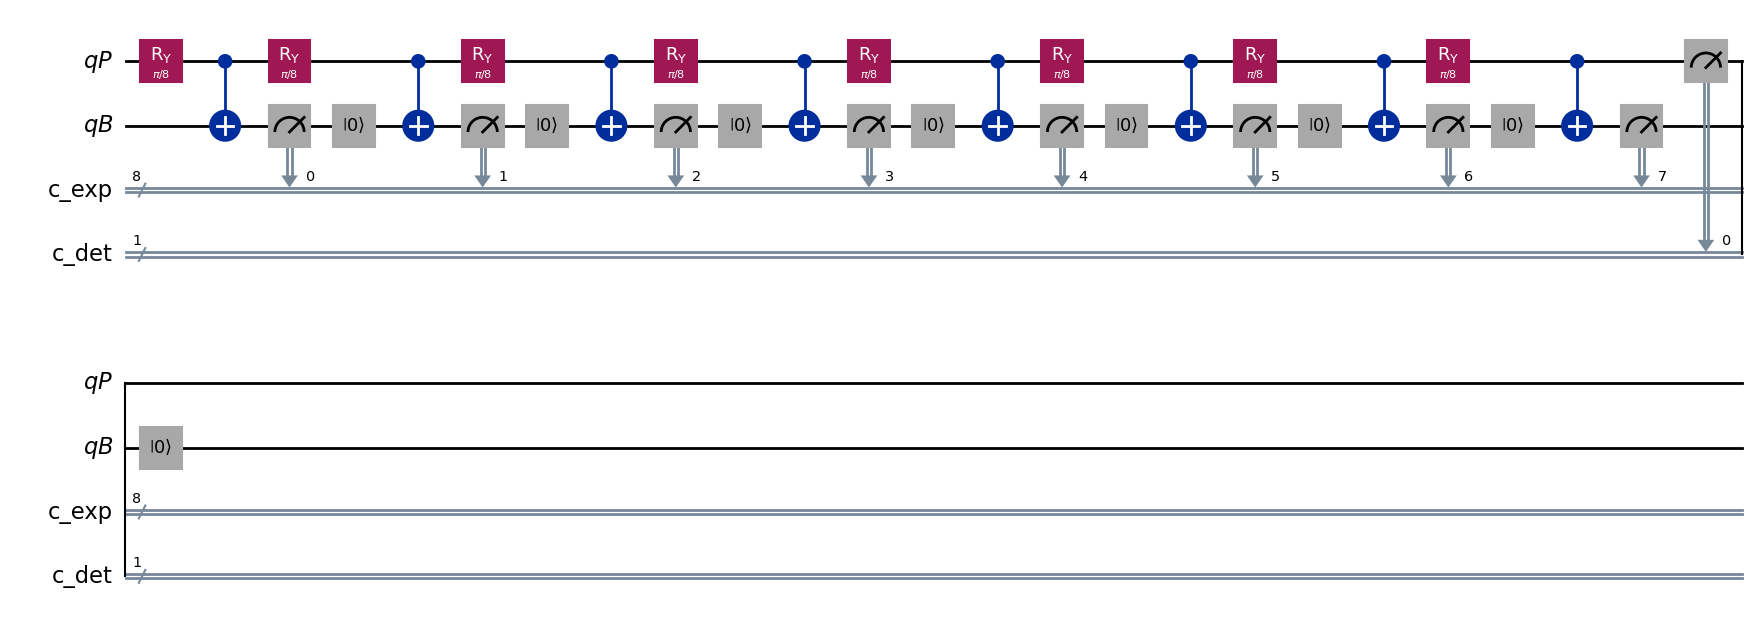

In [10]:
zeno_probe(8).draw('mpl')

# Analytics and plotting

A **analytics layer sweep strategies and Zeno depths** and visualize how they affect **EV**, **turns**, **gates**, and **probes**.

**How it works**
- Replaces simulator shots with an **analytic Zeno model**:  
  $( p_{\text{explode}} \approx \pi^2/(4N))$, clamped to $([0, 0.95])$;  
  if a probed region contains a ship: `found = 1 - p_explosion`, `empty = 0`;  
  if it doesn’t: `empty = 1`, `found = explosion = 0`.
- Runs **symmetric duels** (both sides use the same `(method, N)`), then averages the metrics.
- Provides **sweep** + **ranking** utilities and a few **matplotlib** plots (EV vs `N`, strategy×`N` heatmap, density×`N` heatmap).


In [11]:
def analytic_outcomes_contains(N: int) -> Dict[str, float]:
    """
    Compute analytic outcome probabilities when the probed subset **does contain** ≥1 ship.

    Purpose
    -------
    Provide a fast, closed-form approximation to the Zeno probe outcomes for a "hit" region,
    avoiding simulator shots.

    Parameters
    ----------
    N : int
        Zeno depth (number of weak interrogation steps). Must be >= 1.

    Returns
    -------
    Dict[str, float]
        A dictionary with probabilities summing to ~1:
        {
          'explosion': p_explosion,
          'found': 1 - p_explosion,
          'empty': 0.0
        }

    Notes
    -----
    - Uses the scaling p_explosion ≈ π² / (4N) from the Zeno-limit intuition, clamped
      to [0, 0.95] for numerical sanity.
    - This is an approximation; use Aer simulation if you need hardware-level fidelity.
    """
    if N < 1:
        raise ValueError("N must be >= 1")
    p_explosion = min(0.95, (math.pi ** 2) / (4.0 * N))
    p_found = max(0.0, 1.0 - p_explosion)
    return {"explosion": p_explosion, "found": p_found, "empty": 0.0}


def analytic_outcomes_empty(N: int) -> Dict[str, float]:
    """
    Compute analytic outcome probabilities when the probed subset is **empty** (no ship).

    Purpose
    -------
    Provide a fast idealized model for a "miss" region: pure "empty" detection.

    Parameters
    ----------
    N : int
        Zeno depth. Included for interface symmetry; not used here.

    Returns
    -------
    Dict[str, float]
        {'explosion': 0.0, 'found': 0.0, 'empty': 1.0}

    Notes
    -----
    - In the ideal model, an empty region never explodes and ends as "empty".
    - If you want to model false positives/negatives, perturb these probabilities.
    """
    return {"explosion": 0.0, "found": 0.0, "empty": 1.0}


@dataclass
class Player:
    """
    Minimal player state for the analytic duel.

    Attributes
    ----------
    name : str
        Player label, e.g., 'A' or 'B'.
    method : str
        Scanning strategy: 'rows', 'cols', or 'binary'.
    N : int
        Zeno depth used by this player.
    rng : random.Random
        RNG for sampling outcomes (keeps runs reproducible).
    scanner : ScannerState
        Queue/iterator of regions to probe (from v8 helpers).
    found_cnt : int
        Count of 'found' outcomes (interaction-free).
    expl_cnt : int
        Count of explosions.
    probes : int
        Probes executed so far.
    gates : int
        Rough two-qubit cost proxy (≈ N per probe).
    turns_used : int
        Turn accounting: +1 per probe + explosion penalties.
    """
    name: str
    method: str
    N: int
    rng: random.Random
    scanner: "ScannerState"
    found_cnt: int = 0
    expl_cnt: int = 0
    probes: int = 0
    gates: int = 0
    turns_used: int = 0


def take_turn_analytic(
    attacker: Player,
    defender_board: List[List[int]],
    penalty: int = 1,
) -> str:
    """
    Play a single analytic-model turn; sample outcome and update game state.

    Purpose
    -------
    Provide a fast surrogate for the simulator-based `take_turn` by using
    analytic outcome probabilities (no Aer, no shots).

    Parameters
    ----------
    attacker : Player
        Player taking the turn (mutated in place).
    defender_board : List[List[int]]
        Opponent's board; one random ship in the probed subset is removed on explosion.
    penalty : int, optional
        Explosion penalty added to `turns_used` on explosions, by default 1.

    Returns
    -------
    str
        One of: 'found' | 'explosion' | 'empty' | 'skip' (if no regions available).

    Notes
    -----
    - Uses `next_subset` / `feedback` to maintain the region queue.
    - If the probed subset contains a ship, calls `analytic_outcomes_contains(N)`;
      otherwise `analytic_outcomes_empty(N)`.
    """
    # Get next subset; if queue is empty, reinitialize it
    subset = next_subset(attacker.scanner)
    if not subset:
        attacker.scanner = make_scanner(attacker.method, attacker.scanner.M)
        subset = next_subset(attacker.scanner)
    if not subset:
        return "skip"

    contains = subset_has_ship(defender_board, subset)

    # Choose analytic outcome distribution
    stats = analytic_outcomes_contains(attacker.N) if contains else analytic_outcomes_empty(attacker.N)

    # Sample one outcome
    r = attacker.rng.random()
    if r < stats["explosion"]:
        outcome = "explosion"
    elif r < stats["explosion"] + stats["found"]:
        outcome = "found"
    else:
        outcome = "empty"

    # Base accounting
    attacker.probes += 1
    attacker.gates += attacker.N
    attacker.turns_used += 1

    # Subdivide on positive signal
    positive = outcome in ("found", "explosion")
    feedback(attacker.scanner, subset, positive=positive)

    # Score updates and side effects
    if outcome == "found":
        attacker.found_cnt += 1
    elif outcome == "explosion":
        attacker.expl_cnt += 1
        attacker.turns_used += penalty
        remove_random_ship_in_subset(defender_board, subset, seed=attacker.rng.randrange(10**9))

    return outcome


def duel_eval_analytic(
    M: int,
    S: int,
    method: str,
    N: int,
    round_limit: int = 20,
    penalty: int = 1,
    seed: int = 1234,
) -> Dict[str, float]:
    """
    Evaluate a **symmetric** duel with the analytic outcome model.

    Purpose
    -------
    Quickly approximate performance for a given `(method, N)` by having both players
    use the same settings and averaging their metrics.

    Parameters
    ----------
    M : int
        Board dimension (M×M).
    S : int
        Number of 1×1 ships placed uniformly at random.
    method : str
        Scanning strategy: 'rows', 'cols', or 'binary'.
    N : int
        Zeno depth per probe.
    round_limit : int, optional
        Maximum rounds (A then B per round), by default 20.
    penalty : int, optional
        Explosion penalty added to `turns_used`, by default 1.
    seed : int, optional
        RNG seed, by default 1234.

    Returns
    -------
    Dict[str, float]
        Averaged metrics over A and B:
        {
          'EV', 'gates', 'turns', 'probes', 'rounds'
        }

    Notes
    -----
    - EV is computed as `Found / max(Explosions, 1)` per player before averaging.
    - Stops early if either board has no ships remaining.
    """
    board_A = random_board(M, S, seed + 1)
    board_B = random_board(M, S, seed + 2)

    A = Player("A", method, N, random.Random(seed + 3), make_scanner(method, M))
    B = Player("B", method, N, random.Random(seed + 4), make_scanner(method, M))

    rounds = 0
    for _ in range(round_limit):
        if ships_remaining(board_B) == 0 or ships_remaining(board_A) == 0:
            break
        take_turn_analytic(A, board_B, penalty)
        if ships_remaining(board_B) == 0 or ships_remaining(board_A) == 0:
            break
        take_turn_analytic(B, board_A, penalty)
        rounds += 1

    EV_A = A.found_cnt / max(A.expl_cnt, 1)
    EV_B = B.found_cnt / max(B.expl_cnt, 1)

    return {
        "EV": 0.5 * (EV_A + EV_B),
        "gates": 0.5 * (A.gates + B.gates),
        "turns": 0.5 * (A.turns_used + B.turns_used),
        "probes": 0.5 * (A.probes + B.probes),
        "rounds": float(rounds),
    }


METHODS = ["rows", "cols", "binary"]


def sweep_methods_N(
    M: int,
    density: float,
    N_list: List[int],
    methods: List[str] = METHODS,
    round_limit: int = 20,
    penalty: int = 1,
    trials: int = 8,
    seed: int = 10,
) -> pd.DataFrame:
    """
    Sweep over (method, N) with multiple trials using the analytic duel evaluator.

    Purpose
    -------
    Build a compact table summarizing EV, gates, turns, and probes for each
    (strategy, Zeno depth) combination.

    Parameters
    ----------
    M : int
        Board dimension (M×M).
    density : float
        Ship density in [0,1]; S = round(density * M * M).
    N_list : List[int]
        Zeno depths to evaluate.
    methods : List[str], optional
        Strategies to test, by default ['rows','cols','binary'].
    round_limit : int, optional
        Max rounds per evaluation, by default 20.
    penalty : int, optional
        Explosion penalty (turns), by default 1.
    trials : int, optional
        Monte Carlo trials per combo, by default 8.
    seed : int, optional
        Base RNG seed, by default 10.

    Returns
    -------
    pandas.DataFrame
        Columns:
        ['method','N','EV','gates','turns','probes','EV_per_gate','EV_per_turn'].
    """
    S = max(1, int(round(density * M * M)))
    rows = []
    for method in methods:
        for N in N_list:
            EV = gates = turns = probes = 0.0
            for k in range(trials):
                res = duel_eval_analytic(
                    M, S, method, N, round_limit=round_limit, penalty=penalty, seed=seed + 100 * k + N
                )
                EV += res["EV"]
                gates += res["gates"]
                turns += res["turns"]
                probes += res["probes"]
            EV /= trials
            gates /= trials
            turns /= trials
            probes /= trials
            rows.append(
                (
                    method,
                    int(N),
                    float(EV),
                    float(gates),
                    float(turns),
                    float(probes),
                    float(EV / (gates if gates > 0 else 1.0)),
                    float(EV / (turns if turns > 0 else 1.0)),
                )
            )
    return pd.DataFrame(
        rows,
        columns=["method", "N", "EV", "gates", "turns", "probes", "EV_per_gate", "EV_per_turn"],
    )


def recommend(
    df: pd.DataFrame,
    budget_type: Optional[str] = None,
    budget: Optional[float] = None,
) -> pd.DataFrame:
    """
    Rank strategy options by EV, with optional gate/turn budget filtering.

    Purpose
    -------
    Provide an easy way to select top performers, optionally constrained by
    total gate cost or total turns.

    Parameters
    ----------
    df : pandas.DataFrame
        Table from `sweep_methods_N(...)`.
    budget_type : Optional[str], optional
        One of {None, 'gates', 'turns'}. If set, only keep rows with cost ≤ `budget`.
    budget : Optional[float], optional
        Threshold for the chosen `budget_type`.

    Returns
    -------
    pandas.DataFrame
        Ranked view (best first). Sorting order:
        EV (desc), then budgeted cost (asc if filtered), then probes (asc).

    Notes
    -----
    - If the budget filter removes all rows, we fallback to the unfiltered table.
    """
    if budget_type in ("gates", "turns") and budget is not None:
        filt = df[df[budget_type] <= budget]
        if len(filt) == 0:
            filt = df.copy()
    else:
        filt = df.copy()

    sort_cols = ["EV"] + ([budget_type] if budget_type in ("gates", "turns") else []) + ["probes"]
    ascending = [False] + ([True] if budget_type in ("gates", "turns") else []) + [True]
    return filt.sort_values(by=sort_cols, ascending=ascending, ignore_index=True)


def plot_ev_vs_N(df: pd.DataFrame, title: str = "EV vs Zeno depth N by strategy") -> None:
    """
    Plot EV as a function of N for each strategy (one chart).

    Purpose
    -------
    Visualize the tradeoff trend of Zeno depth across strategies.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: ['method','N','EV'].
    title : str, optional
        Figure title, by default 'EV vs Zeno depth N by strategy'.

    Returns
    -------
    None
        Displays a matplotlib figure.

    Notes
    -----
    - Uses default matplotlib colors. One figure per call.
    """
    plt.figure()
    for method in sorted(df["method"].unique()):
        sub = df[df["method"] == method].sort_values("N")
        plt.plot(sub["N"].values, sub["EV"].values, marker="o", label=method)
    plt.xlabel("Zeno depth N")
    plt.ylabel("EV (Found / max(Explosions, 1))")
    plt.title(title)
    plt.legend()
    plt.show()


def heatmap_methods_vs_N(df: pd.DataFrame, title: str = "EV heatmap: strategy × N") -> None:
    """
    Heatmap of EV with y=strategy, x=N.

    Purpose
    -------
    Offer a compact comparison of EV across strategies and Zeno depths.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: ['method','N','EV'].
    title : str, optional
        Figure title, by default 'EV heatmap: strategy × N'.

    Returns
    -------
    None
        Displays a matplotlib figure.
    """
    methods = sorted(df["method"].unique())
    Ns = sorted(int(x) for x in df["N"].unique())
    mat = np.zeros((len(methods), len(Ns)), dtype=float)
    for i, m in enumerate(methods):
        for j, N in enumerate(Ns):
            mat[i, j] = float(df[(df["method"] == m) & (df["N"] == N)]["EV"].mean())
    plt.figure()
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.xticks(ticks=range(len(Ns)), labels=Ns)
    plt.yticks(ticks=range(len(methods)), labels=methods)
    plt.xlabel("Zeno depth N")
    plt.ylabel("Strategy")
    plt.title(title)
    plt.colorbar(label="EV")
    plt.show()


def heatmap_density_vs_N(
    M: int,
    method: str,
    N_list: List[int],
    densities: List[float],
    round_limit: int = 20,
    penalty: int = 1,
    trials: int = 6,
    seed: int = 17,
    title: Optional[str] = None,
) -> pd.DataFrame:
    """
    Compute & plot EV heatmap over (density × N) for a single strategy.

    Purpose
    -------
    Show how the optimal Zeno depth depends on ship density for a fixed strategy.

    Parameters
    ----------
    M : int
        Board dimension (M×M).
    method : str
        Strategy to evaluate: 'rows', 'cols', or 'binary'.
    N_list : List[int]
        Zeno depths to test.
    densities : List[float]
        Ship densities to test (0..1); S = round(density * M * M).
    round_limit : int, optional
        Max rounds per evaluation, by default 20.
    penalty : int, optional
        Explosion penalty, by default 1.
    trials : int, optional
        Monte Carlo trials per setting, by default 6.
    seed : int, optional
        Base RNG seed, by default 17.
    title : Optional[str], optional
        Title override for the figure.

    Returns
    -------
    pandas.DataFrame
        Long form table with columns: ['density','N','EV'] used to render the heatmap.

    Notes
    -----
    - Displays a single matplotlib figure.
    - Returned table can be saved or further analyzed downstream.
    """
    # Build the long-form table
    rows = []
    for d in densities:
        df = sweep_methods_N(
            M, d, N_list, methods=[method], round_limit=round_limit, penalty=penalty, trials=trials, seed=seed
        )
        for _, r in df.iterrows():
            rows.append({"density": float(d), "N": int(r["N"]), "EV": float(r["EV"])})
    tab = pd.DataFrame(rows)

    # Pivot to a matrix for plotting
    ds = sorted(tab["density"].unique())
    Ns = sorted(int(x) for x in tab["N"].unique())
    mat = np.zeros((len(ds), len(Ns)), dtype=float)
    for i, d in enumerate(ds):
        for j, N in enumerate(Ns):
            mat[i, j] = float(tab[(tab["density"] == d) & (tab["N"] == N)]["EV"].mean())

    #  heatmap
    plt.figure()
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.xticks(ticks=range(len(Ns)), labels=Ns)
    plt.yticks(ticks=range(len(ds)), labels=[f"{x:.2f}" for x in ds])
    plt.xlabel("Zeno depth N")
    plt.ylabel("Ship density")
    plt.title(title or f"EV heatmap: density × N (method={method})")
    plt.colorbar(label="EV")
    plt.show()

    return tab


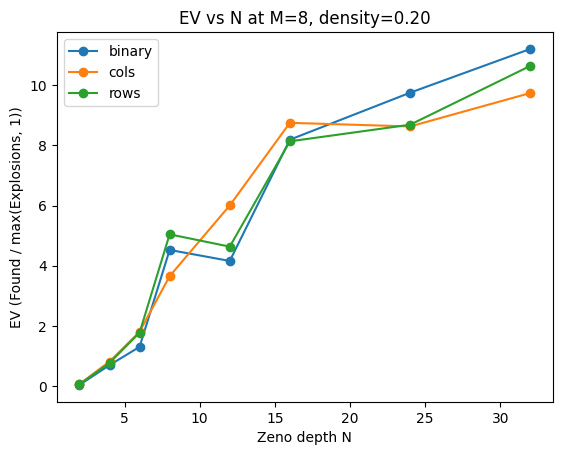

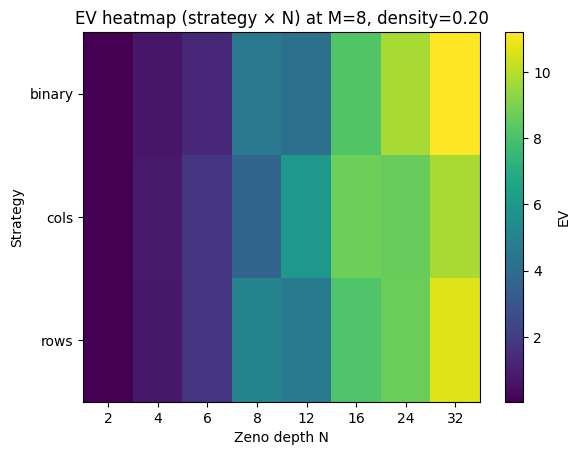

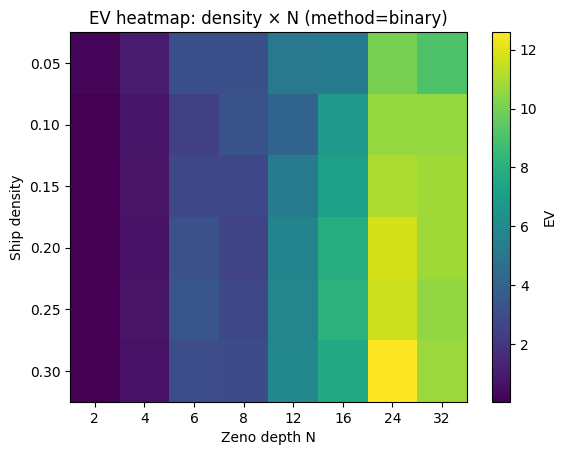

In [12]:
# PLOTS 

# Parameters
M = 8
density = 0.20
N_list = [2, 4, 6, 8, 12, 16, 24, 32]

# Build table with the fast analytic model
df = sweep_methods_N(
    M, density, N_list,
    methods=['rows', 'cols', 'binary'],
    round_limit=20, penalty=1, trials=8, seed=11
)

# Plot 1: EV vs N per strategy (one chart)
plot_ev_vs_N(df, title=f'EV vs N at M={M}, density={density:.2f}')

# Plot 2: Heatmap (strategy × N) → EV (one chart)
heatmap_methods_vs_N(df, title=f'EV heatmap (strategy × N) at M={M}, density={density:.2f}')

# Plot 3: Heatmap (density × N) for a single strategy (binary)
_ = heatmap_density_vs_N(
    M, method='binary', N_list=N_list,
    densities=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    round_limit=18, penalty=1, trials=6, seed=21
)



### References
[1] W. M. Itano, D. J. Heinzen, J. J. Bollinger, D. J. Wineland, “Quantum Zeno effect,” *Phys. Rev. A* **41**, 2295 (1990).

[2] P. Facchi, S. Pascazio, “Quantum Zeno dynamics: Mathematical and physical aspects,” *J. Phys. A: Math. Theor.* **41**, 493001 (2008).

[3] O. Hosten, M. T. Rakher, J. T. Barreiro, N. A. Peters, P. G. Kwiat, “Counterfactual computation with interaction-free measurements,” *Nature* **439**, 949–952 (2006).

[4] K. Tsegaye, A. Goobar, A. Karlsson, G. Björk, M. Y. Loh, K. H. Lim, “Efficient interaction-free measurements in a high-finesse interferometer,” *Phys. Rev. A* **57**, 3987–3990 (1998).

[5] D.-Z. Du, F. K. Hwang, *Combinatorial Group Testing and Its Applications*, 2nd ed., World Scientific (2000).

[6] Qiskit Community, *Learn Quantum Computation using Qiskit*, https://qiskit.org/learn (access: general textbook; chapters on interference and mid-circuit measure/reset).